In [68]:
import numpy as np
import pandas as pd
import plotly.graph_objs as go
import warnings
warnings.filterwarnings("ignore")

In [69]:
df = pd.read_csv(r"C:\Users\91984\Downloads\TCS_historical_data_Daily_5_Years.csv")

In [70]:
df

,Date,Open,High,Low,Close,Volume,Exchange
0,2025-10-03,2924.0,2924.00,2891.10,2903.00,2799767,NSE
1,2025-10-01,2891.0,2924.80,2866.60,2916.80,1941068,NSE
2,2025-09-30,2911.0,2915.30,2885.10,2894.90,2228350,NSE
3,2025-09-29,2916.0,2929.30,2894.00,2904.30,3084635,NSE
4,2025-09-26,2941.0,2954.80,2891.30,2905.40,3876112,NSE
...,...,...,...,...,...,...,...
1227,2020-10-23,2687.8,2702.00,2670.10,2686.80,3499372,NSE
1228,2020-10-22,2661.0,2686.65,2638.10,2671.15,5262311,NSE
1229,2020-10-21,2739.0,2749.00,2663.05,2675.40,4570175,NSE
1230,2020-10-20,2725.0,2759.90,2717.95,2739.00,3406298,NSE


In [71]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1232 entries, 0 to 1231
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Date      1232 non-null   object 
 1   Open      1232 non-null   float64
 2   High      1232 non-null   float64
 3   Low       1232 non-null   float64
 4   Close     1232 non-null   float64
 5   Volume    1232 non-null   int64  
 6   Exchange  1232 non-null   object 
dtypes: float64(4), int64(1), object(2)
memory usage: 67.5+ KB


In [72]:
df.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Exchange'], dtype='object')

In [73]:
df.drop(columns=['Exchange'],inplace=True)

In [74]:
df.describe()

,Open,High,Low,Close,Volume
count,1232.000000,1232.000000,1232.000000,1232.000000,1.232000e+03
mean,3512.356006,3543.268709,3480.006818,3510.871510,2.429368e+06
std,407.145359,412.034451,403.722241,407.448146,1.293514e+06
min,2604.000000,2655.000000,2600.050000,2604.600000,6.505700e+04
25%,3218.125000,3243.700000,3192.000000,3215.325000,1.622162e+06
50%,3435.000000,3464.850000,3410.950000,3440.875000,2.084541e+06
75%,3810.000000,3840.312500,3772.250000,3810.950000,2.898771e+06
max,4576.000000,4592.250000,4512.000000,4553.750000,1.350916e+07


In [75]:
df=df.copy(deep=True)
col=['Open', 'High', 'Low', 'Close', 'Volume']

In [76]:
df['Date'] = pd.to_datetime(df['Date'])
#df.set_index('Date', inplace=True)

In [77]:
import pandas as pd

# 1. Setup your date range to DELETE
start_date_to_remove = '2020-10-01'
end_date_to_remove   = '2020-12-13'

# 2. Ensure your 'Date' column is actual datetime objects (Critical step)
# Replace 'df' with your actual dataframe name
df['Date'] = pd.to_datetime(df['Date'])

# 3. Apply the Filter
# Logic: Keep rows where Date is BEFORE start OR AFTER end
df = df[ (df['Date'] < start_date_to_remove) | (df['Date'] > end_date_to_remove) ]

# Optional: Reset index if you want the row numbers to be continuous again
df = df.reset_index(drop=True)

# 4. Verify
print(f"New Min Date: {df['Date'].min()}")
print(f"New Max Date: {df['Date'].max()}")

New Min Date: 2020-12-14 00:00:00
New Max Date: 2025-10-03 00:00:00


for i in col:
    q25,q75=np.percentile(df[i],25),np.percentile(df[i],75)
    IQR = q75 - q25
    Threshold=IQR*1.5
    lower,upper=q25-Threshold,q75+Threshold
    outliers=[j for j in df[i] if j < lower or j > upper]
    for k in outliers:
        data_1=df.drop(df.index[df[i]==k],axis=0)

In [78]:
df

,Date,Open,High,Low,Close,Volume
0,2025-10-03,2924.0,2924.0,2891.10,2903.00,2799767
1,2025-10-01,2891.0,2924.8,2866.60,2916.80,1941068
2,2025-09-30,2911.0,2915.3,2885.10,2894.90,2228350
3,2025-09-29,2916.0,2929.3,2894.00,2904.30,3084635
4,2025-09-26,2941.0,2954.8,2891.30,2905.40,3876112
...,...,...,...,...,...,...
1188,2020-12-18,2868.0,2898.0,2846.20,2861.00,6076692
1189,2020-12-17,2811.0,2853.7,2805.00,2838.20,2863460
1190,2020-12-16,2779.0,2819.8,2760.45,2814.20,2565149
1191,2020-12-15,2786.0,2794.7,2755.00,2761.55,2365509


In [79]:
#df=data_1
dt=df.copy()

In [80]:
df

,Date,Open,High,Low,Close,Volume
0,2025-10-03,2924.0,2924.0,2891.10,2903.00,2799767
1,2025-10-01,2891.0,2924.8,2866.60,2916.80,1941068
2,2025-09-30,2911.0,2915.3,2885.10,2894.90,2228350
3,2025-09-29,2916.0,2929.3,2894.00,2904.30,3084635
4,2025-09-26,2941.0,2954.8,2891.30,2905.40,3876112
...,...,...,...,...,...,...
1188,2020-12-18,2868.0,2898.0,2846.20,2861.00,6076692
1189,2020-12-17,2811.0,2853.7,2805.00,2838.20,2863460
1190,2020-12-16,2779.0,2819.8,2760.45,2814.20,2565149
1191,2020-12-15,2786.0,2794.7,2755.00,2761.55,2365509


In [81]:
fig = go.Figure([go.Ohlc(x=dt.Date,
                         open=dt.Open,
                         high=dt.High,
                         low=dt.Low,
                         close=dt.Close)])

fig.update_layout(
    xaxis_rangeslider_visible=False,
    width=1200,      # change width
    height=700      # change height
)

fig.show()


In [82]:
fig = go.Figure(go.Bar(x=dt.Date, y=dt.Volume, name='Volume', marker_color='red'))
fig.update_layout(
    width=1000,      # change width
    height=500      # change height
)
fig.show()

In [83]:
df

,Date,Open,High,Low,Close,Volume
0,2025-10-03,2924.0,2924.0,2891.10,2903.00,2799767
1,2025-10-01,2891.0,2924.8,2866.60,2916.80,1941068
2,2025-09-30,2911.0,2915.3,2885.10,2894.90,2228350
3,2025-09-29,2916.0,2929.3,2894.00,2904.30,3084635
4,2025-09-26,2941.0,2954.8,2891.30,2905.40,3876112
...,...,...,...,...,...,...
1188,2020-12-18,2868.0,2898.0,2846.20,2861.00,6076692
1189,2020-12-17,2811.0,2853.7,2805.00,2838.20,2863460
1190,2020-12-16,2779.0,2819.8,2760.45,2814.20,2565149
1191,2020-12-15,2786.0,2794.7,2755.00,2761.55,2365509


In [84]:
dt['EMA_9'] = dt['Close'].ewm(5).mean().shift()
dt['SMA_50'] = dt['Close'].rolling(50).mean().shift()
dt['SMA_100'] = dt['Close'].rolling(100).mean().shift()
dt['SMA_200'] = dt['Close'].rolling(200).mean().shift()

fig = go.Figure()
fig.add_trace(go.Scatter(x=dt.Date, y=dt.EMA_9, name='EMA 9'))
fig.add_trace(go.Scatter(x=dt.Date, y=dt.SMA_50, name='SMA 50'))
fig.add_trace(go.Scatter(x=dt.Date, y=dt.SMA_100, name='SMA 100'))
fig.add_trace(go.Scatter(x=dt.Date, y=dt.SMA_200, name='SMA 200'))
fig.add_trace(go.Scatter(x=dt.Date, y=dt.Close, name='Close', line_color='dimgray', opacity=0.3))
fig.update_layout(
    width=1100,      # change width
    height=700      # change height
)
fig.show()

In [85]:
df

,Date,Open,High,Low,Close,Volume
0,2025-10-03,2924.0,2924.0,2891.10,2903.00,2799767
1,2025-10-01,2891.0,2924.8,2866.60,2916.80,1941068
2,2025-09-30,2911.0,2915.3,2885.10,2894.90,2228350
3,2025-09-29,2916.0,2929.3,2894.00,2904.30,3084635
4,2025-09-26,2941.0,2954.8,2891.30,2905.40,3876112
...,...,...,...,...,...,...
1188,2020-12-18,2868.0,2898.0,2846.20,2861.00,6076692
1189,2020-12-17,2811.0,2853.7,2805.00,2838.20,2863460
1190,2020-12-16,2779.0,2819.8,2760.45,2814.20,2565149
1191,2020-12-15,2786.0,2794.7,2755.00,2761.55,2365509


In [86]:
def RSI(dt, n=14):
    close = dt['Close']
    delta = close.diff()
    delta = delta[1:]
    pricesUp = delta.copy()
    pricesDown = delta.copy()
    pricesUp[pricesUp < 0] = 0
    pricesDown[pricesDown > 0] = 0
    rollUp = pricesUp.rolling(n).mean()
    rollDown = pricesDown.abs().rolling(n).mean()
    rs = rollUp / rollDown
    rsi = 100.0 - (100.0 / (1.0 + rs))
    return rsi

num_days = 365
dt['RSI'] = RSI(dt).fillna(0)

fig = go.Figure(
    go.Scatter(
        x=dt.Date.tail(num_days),
        y=dt.RSI.tail(num_days)
    )
)

fig.update_layout(
    width=1100,   # change width
    height=600,  # change height
    title="RSI Chart"
)

fig.show()

In [87]:
def stochastic(dt, k, d):
    dt = dt.copy()
    low_min  = dt['Low'].rolling(window=k).min()
    high_max = dt['High'].rolling( window=k).max()
    dt['stoch_k'] = 100 * (dt['Close'] - low_min)/(high_max - low_min)
    dt['stoch_d'] = dt['stoch_k'].rolling(window=d).mean()
    return dt

stochs = stochastic(dt, k=14, d=3)

fig = go.Figure()
fig.add_trace(go.Scatter(x=dt.Date.tail(365), y=stochs.stoch_k.tail(365), name='K stochastic'))
fig.add_trace(go.Scatter(x=dt.Date.tail(365), y=stochs.stoch_d.tail(365), name='D stochastic'))
fig.update_layout(
    width=1100,   # change width
    height=600,  # change height
    title="Stochastic"
)
fig.show()

In [88]:
df['Date'] = pd.to_datetime(df['Date'])

In [89]:
#pip install vaderSentiment

In [90]:
pip install yfinance 

Note: you may need to restart the kernel to use updated packages.


In [91]:
pip install GoogleNews

Note: you may need to restart the kernel to use updated packages.


In [92]:
pip install snscrape

Note: you may need to restart the kernel to use updated packages.


In [93]:
import pandas as pd
import requests
import io

# 1. Define the API Endpoint for GDELT 2.0 Doc API
# We need two separate calls: one for Sentiment (Tone) and one for Volume.
base_url = "https://api.gdeltproject.org/api/v2/doc/doc"

# Search Query: Use quotes for exact match
query = '"Tata Consultancy Services"'

# Define parameters for 5 Years of Data
# format=csv : Get data as CSV
# timespan=5y : Last 5 years
params_tone = {
    'query': query,
    'mode': 'timelinetone',  # Requests the Average Tone (Sentiment)
    'format': 'csv',
    'timespan': '5y'
}

params_vol = {
    'query': query,
    'mode': 'timelinevol',   # Requests the Volume (Intensity)
    'format': 'csv',
    'timespan': '5y'
}

print("Fetching Sentiment Data...")
response_tone = requests.get(base_url, params=params_tone)
data_tone = pd.read_csv(io.StringIO(response_tone.text))

print("Fetching Volume Data...")
response_vol = requests.get(base_url, params=params_vol)
data_vol = pd.read_csv(io.StringIO(response_vol.text))

# 2. Inspect and Clean the Data
# The API returns columns like 'Date' and 'Series'.
# Tone 'Series' = Average Tone (Negative to Positive)
# Volume 'Series' = Percentage of global news devoted to this topic

# Rename columns for clarity
data_tone = data_tone.rename(columns={'Series': 'Sentiment_Score'})
data_vol = data_vol.rename(columns={'Series': 'News_Volume_Percent'})

# Convert Date to datetime objects
data_tone['Date'] = pd.to_datetime(data_tone['Date'])
data_vol['Date'] = pd.to_datetime(data_vol['Date'])

# 3. Merge them into one dataframe
data = pd.merge(data_tone, data_vol, on='Date', how='inner')

# 4. Save to CSV for your LSTM
output_filename = "TCS_5Year_Sentiment.csv"
data.to_csv(output_filename, index=False)

print(f"Success! Data saved to {output_filename}")
data

Fetching Sentiment Data...
Fetching Volume Data...
Success! Data saved to TCS_5Year_Sentiment.csv


,Date,Sentiment_Score,Value_x,News_Volume_Percent,Value_y
0,2020-12-14,Average Tone,3.7478,Volume Intensity,0.0106
1,2020-12-15,Average Tone,3.4164,Volume Intensity,0.0074
2,2020-12-16,Average Tone,3.4840,Volume Intensity,0.0034
3,2020-12-17,Average Tone,-0.5868,Volume Intensity,0.0134
4,2020-12-18,Average Tone,0.6973,Volume Intensity,0.0154
...,...,...,...,...,...
1802,2025-12-08,Average Tone,0.0587,Volume Intensity,0.0044
1803,2025-12-09,Average Tone,-1.2390,Volume Intensity,0.0057
1804,2025-12-10,Average Tone,1.0052,Volume Intensity,0.0070
1805,2025-12-11,Average Tone,2.0040,Volume Intensity,0.0077


In [94]:
start_date_to_remove = '2025-10-04'
end_date_to_remove   = '2025-12-12'

# 2. Ensure your 'Date' column is actual datetime objects (Critical step)
# Replace 'df' with your actual dataframe name
data['Date'] = pd.to_datetime(data['Date'])

# 3. Apply the Filter
# Logic: Keep rows where Date is BEFORE start OR AFTER end
data1 = data[ (data['Date'] < start_date_to_remove) | (data['Date'] > end_date_to_remove) ]

# Optional: Reset index if you want the row numbers to be continuous again
data1 = data.reset_index(drop=True)


In [95]:
df['Date'] = pd.to_datetime(df['Date'])

# 2. Sort by Date Ascending (Oldest to Newest)
# LSTMs strictly require time to flow forward (2020 -> 2025).
df = df.sort_values('Date', ascending=True)

print("Sorted Stock Data:")
df

Sorted Stock Data:


,Date,Open,High,Low,Close,Volume
1192,2020-12-14,2802.0,2804.0,2756.25,2797.70,2483658
1191,2020-12-15,2786.0,2794.7,2755.00,2761.55,2365509
1190,2020-12-16,2779.0,2819.8,2760.45,2814.20,2565149
1189,2020-12-17,2811.0,2853.7,2805.00,2838.20,2863460
1188,2020-12-18,2868.0,2898.0,2846.20,2861.00,6076692
...,...,...,...,...,...,...
4,2025-09-26,2941.0,2954.8,2891.30,2905.40,3876112
3,2025-09-29,2916.0,2929.3,2894.00,2904.30,3084635
2,2025-09-30,2911.0,2915.3,2885.10,2894.90,2228350
1,2025-10-01,2891.0,2924.8,2866.60,2916.80,1941068


In [96]:
# 1. Rename the numeric columns to meaningful names
# Value_x is your Sentiment Score, Value_y is your Volume.
data1 = data1.rename(columns={
    'Value_x': 'Sentiment_Score_Numeric',
    'Value_y': 'News_Volume_Numeric'
})

# 2. Select ONLY the columns you need (Date + The Numbers)
# We ignore the columns that just say "Average Tone" text.
data_clean = data1[['Date', 'Sentiment_Score_Numeric', 'News_Volume_Numeric']].copy()

# 3. Ensure Date is in datetime format
data_clean['Date'] = pd.to_datetime(data_clean['Date'])

print("Cleaned Sentiment Data:")
data_clean

Cleaned Sentiment Data:


,Date,Sentiment_Score_Numeric,News_Volume_Numeric
0,2020-12-14,3.7478,0.0106
1,2020-12-15,3.4164,0.0074
2,2020-12-16,3.4840,0.0034
3,2020-12-17,-0.5868,0.0134
4,2020-12-18,0.6973,0.0154
...,...,...,...
1802,2025-12-08,0.0587,0.0044
1803,2025-12-09,-1.2390,0.0057
1804,2025-12-10,1.0052,0.0070
1805,2025-12-11,2.0040,0.0077


In [97]:
# 1. Merge using 'inner' join
# This keeps only the days where you have BOTH Stock Prices AND News Data.
# It automatically aligns the rows by Date.
merged_df = pd.merge(df, data_clean, on='Date', how='inner')

# 2. Final Check
print("Final Merged Dataset:")
print(merged_df.head())
print(f"Total Rows: {len(merged_df)}")

# 3. Save to CSV for your LSTM
merged_df.to_csv("Final_TCS_LSTM_Data.csv", index=False)

Final Merged Dataset:
        Date    Open    High      Low    Close   Volume  \
0 2020-12-14  2802.0  2804.0  2756.25  2797.70  2483658   
1 2020-12-15  2786.0  2794.7  2755.00  2761.55  2365509   
2 2020-12-16  2779.0  2819.8  2760.45  2814.20  2565149   
3 2020-12-17  2811.0  2853.7  2805.00  2838.20  2863460   
4 2020-12-18  2868.0  2898.0  2846.20  2861.00  6076692   

   Sentiment_Score_Numeric  News_Volume_Numeric  
0                   3.7478               0.0106  
1                   3.4164               0.0074  
2                   3.4840               0.0034  
3                  -0.5868               0.0134  
4                   0.6973               0.0154  
Total Rows: 1180


In [98]:
df=merged_df.copy()

In [99]:
df

,Date,Open,High,Low,Close,Volume,Sentiment_Score_Numeric,News_Volume_Numeric
0,2020-12-14,2802.0,2804.0,2756.25,2797.70,2483658,3.7478,0.0106
1,2020-12-15,2786.0,2794.7,2755.00,2761.55,2365509,3.4164,0.0074
2,2020-12-16,2779.0,2819.8,2760.45,2814.20,2565149,3.4840,0.0034
3,2020-12-17,2811.0,2853.7,2805.00,2838.20,2863460,-0.5868,0.0134
4,2020-12-18,2868.0,2898.0,2846.20,2861.00,6076692,0.6973,0.0154
...,...,...,...,...,...,...,...,...
1175,2025-09-26,2941.0,2954.8,2891.30,2905.40,3876112,-0.5091,0.0117
1176,2025-09-29,2916.0,2929.3,2894.00,2904.30,3084635,-0.9238,0.0125
1177,2025-09-30,2911.0,2915.3,2885.10,2894.90,2228350,0.7568,0.0141
1178,2025-10-01,2891.0,2924.8,2866.60,2916.80,1941068,-2.2235,0.0075


In [100]:
df.columns.to_list()

['Date',
 'Open',
 'High',
 'Low',
 'Close',
 'Volume',
 'Sentiment_Score_Numeric',
 'News_Volume_Numeric']

In [101]:
features=[
 'Open',
 'High',
 'Low',
 'Volume',
 'Sentiment_Score_Numeric',
 'News_Volume_Numeric']

In [102]:
from sklearn.preprocessing import MinMaxScaler
scalerx = MinMaxScaler()
scalery = MinMaxScaler()

In [103]:
features

['Open',
 'High',
 'Low',
 'Volume',
 'Sentiment_Score_Numeric',
 'News_Volume_Numeric']

In [104]:
X=scalerx.fit_transform(df[features])

In [105]:
Y=scalery.fit_transform(df[["Close"]])

In [106]:
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest = train_test_split(X,Y,train_size=0.8,random_state=42)

In [107]:
df.shape

(1180, 8)

In [108]:
xtrain.shape

(944, 6)

In [109]:
xtrain = xtrain.reshape((xtrain.shape[0], 1, xtrain.shape[1]))
xtest = xtest.reshape((xtest.shape[0], 1, xtest.shape[1]))

In [110]:
import keras_tuner as kt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# 1. DEFINE YOUR INPUT SHAPE HERE
# time_steps: How many days back to look (e.g., 60 days)
TIME_STEPS = xtrain.shape[1] 
NUM_FEATURES = xtrain.shape[2]# Update this to match your actual number of columns

def build_lstm_model(hp):
    model = Sequential()

    # Tune number of LSTM layers (1–3)
    num_layers = hp.Int("num_lstm_layers", 1, 3)

    for i in range(num_layers):
        # 2. CHECK IF THIS IS THE FIRST LAYER
        if i == 0:
            # First layer MUST have input_shape
            model.add(
                LSTM(
                    units=hp.Int(f"lstm_units_{i}", 32, 256, step=32),
                    return_sequences=(i < num_layers - 1),
                    input_shape=(TIME_STEPS, NUM_FEATURES)  # <--- ADDED HERE
                )
            )
        else:
            # Subsequent layers do not need input_shape
            model.add(
                LSTM(
                    units=hp.Int(f"lstm_units_{i}", 32, 256, step=32),
                    return_sequences=(i < num_layers - 1)
                )
            )

        model.add(Dropout(
            hp.Float(f"dropout_{i}", 0.1, 0.5, step=0.1)
        ))

    # Dense layer tuning
    model.add(Dense(
        units=hp.Int("dense_units", 16, 128, step=16),
        activation="relu"
    ))

    # Output layer
    model.add(Dense(1))

    # Learning rate tuning
    lr = hp.Choice("learning_rate", [1e-2, 1e-3, 5e-4, 1e-4])

    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss="mean_squared_error",
        metrics=["mse"]
    )

    return model

In [111]:
tuner = kt.BayesianOptimization(
    build_lstm_model,
    objective="val_loss",
    max_trials=25,
    directory="lstm_bayesian_tuning",
    project_name="tcs_lstm_v2_new_features",  # <--- CHANGE THIS NAME (e.g., add _v2)
    overwrite=True # <--- Optional: This forces it to overwrite if the folder exists
)

tuner.search(xtrain, ytrain, epochs=15, validation_data=(xtest, ytest))


Trial 25 Complete [00h 00m 19s]
val_loss: 0.001721446868032217

Best val_loss So Far: 0.00025195491616614163
Total elapsed time: 00h 05m 11s


In [112]:
tuner.search(
    xtrain, ytrain,
    epochs=15,
    validation_data=(xtest, ytest),
    verbose=1
)

In [113]:
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print("Best Hyperparameters:", best_hps.values)

Best Hyperparameters: {'num_lstm_layers': 1, 'lstm_units_0': 224, 'dropout_0': 0.2, 'dense_units': 64, 'learning_rate': 0.01, 'lstm_units_1': 96, 'dropout_1': 0.5, 'lstm_units_2': 192, 'dropout_2': 0.5}


In [114]:
best_model = tuner.get_best_models(num_models=1)[0]
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

# If batch size was part of tuning:
if "batch_size" in best_hps.values:
    batch_size = best_hps.get("batch_size")
else:
    batch_size = 32   # fallback

history = best_model.fit(
    xtrain, ytrain,
    validation_data=(xtest, ytest),
    epochs=50,
    batch_size=batch_size,
    verbose=1
)

Epoch 1/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 0.0076 - mse: 0.0076 - val_loss: 0.0020 - val_mse: 0.0020
Epoch 2/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0011 - mse: 0.0011 - val_loss: 3.5421e-04 - val_mse: 3.5421e-04
Epoch 3/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 5.1775e-04 - mse: 5.1775e-04 - val_loss: 7.4612e-04 - val_mse: 7.4612e-04
Epoch 4/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 6.3613e-04 - mse: 6.3613e-04 - val_loss: 3.5062e-04 - val_mse: 3.5062e-04
Epoch 5/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 4.1669e-04 - mse: 4.1669e-04 - val_loss: 2.7044e-04 - val_mse: 2.7044e-04
Epoch 6/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 4.0723e-04 - mse: 4.0723e-04 - val_loss: 2.4723e-04 - val_mse: 2.4723e-04
Epoch 7/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 4.6378e-04 - mse: 4.6378e-04 - val_loss: 2.6172e-04 - val_mse: 2.6172e-04
Epoch 8/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 3.7141e-04 - mse: 3.7141e-04 - val_loss: 

In [115]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

print("x test shape:", xtest.shape)

# Directly predict (no reshape needed)
y_pred1 = best_model.predict(xtest)
y_pred1 = y_pred.flatten()

r2 = r2_score(ytest, y_pred1)

# Change the print statement to reflect the correct metric
print(f" r2 : {r2:.4f}")

x test shape: (236, 1, 6)
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step 
 r2 : 0.9970


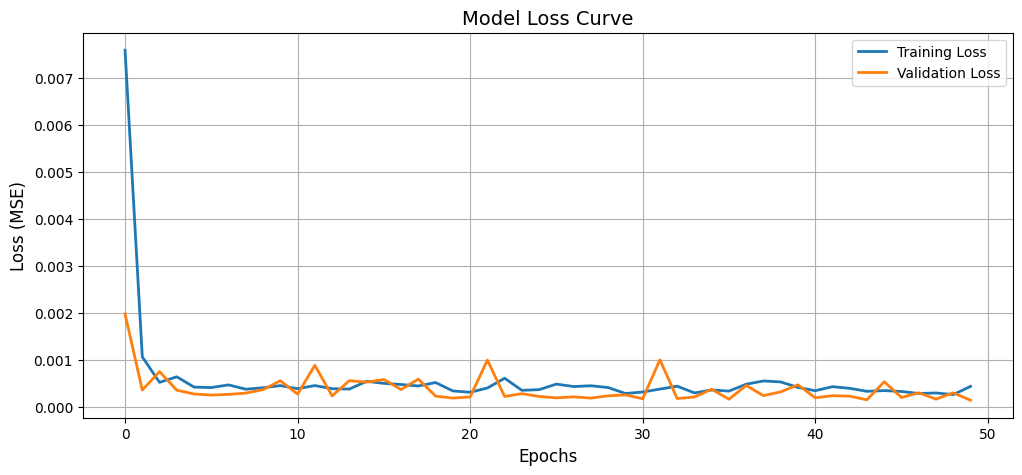

In [116]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(history.history['loss'], label='Training Loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)

plt.title('Model Loss Curve', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss (MSE)', fontsize=12)
plt.legend()
plt.grid(True)
plt.show()

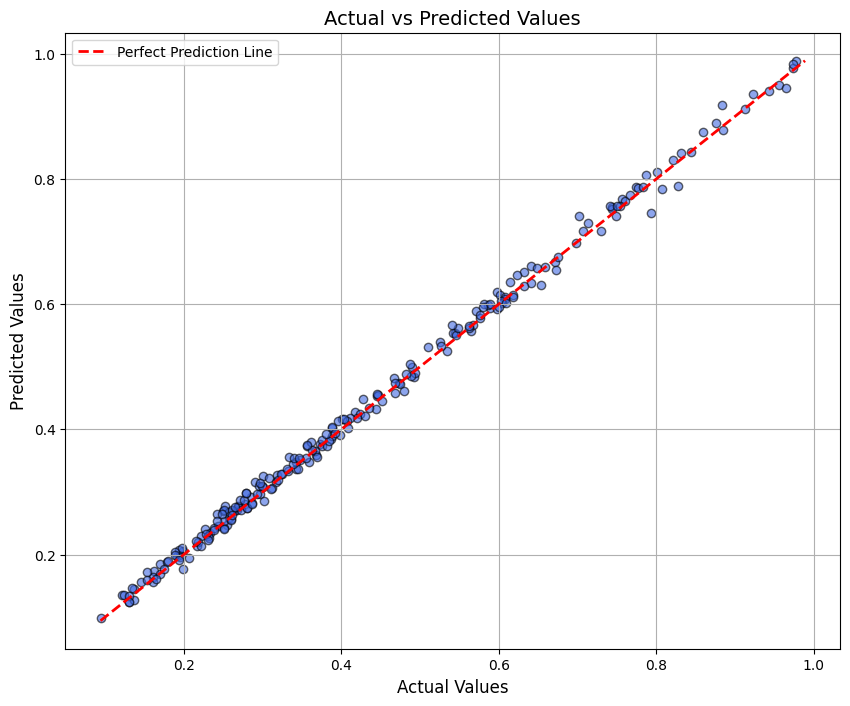

In [117]:
import numpy as np
import matplotlib.pyplot as plt

# Fix shape issues
ytest = np.array(ytest).flatten()
y_pred1 = np.array(y_pred1).flatten()

plt.figure(figsize=(10,8))
plt.scatter(ytest, y_pred1, alpha=0.6, color="royalblue", edgecolor='k')

min_val = min(min(ytest), min(y_pred1))
max_val = max(max(ytest), max(y_pred1))

# Perfect prediction line
plt.plot([min_val, max_val],
         [min_val, max_val],
         color='red',
         linestyle='--',
         linewidth=2,
         label='Perfect Prediction Line')

plt.title('Actual vs Predicted Values', fontsize=14)
plt.xlabel('Actual Values', fontsize=12)
plt.ylabel('Predicted Values', fontsize=12)
plt.legend()
plt.grid(True)
plt.show()


In [118]:
y_pred_reshaped = y_pred1.reshape(-1, 1)
y_pred_actual = scalery.inverse_transform(y_pred_reshaped)

Hence,LSTM is the best one for the prediction

input values are "OPEN ","HIGH ","LOW ","PREV. CLOSE ","ltp ","52W H ","52W L ","VOLUME ","No of trades "

In [119]:
df2 = pd.read_csv(r"C:\Users\91984\Downloads\Quote-Equity-TCS-EQ-15-09-2025-to-15-10-2025.csv")

In [120]:
df2

,Date,series,OPEN,HIGH,LOW,PREV. CLOSE,ltp,close,vwap,52W H,52W L,VOLUME,VALUE,No of trades
0,15-Oct-2025,EQ,"2,971.00","2,979.70","2,951.00","2,960.30","2,970.00","2,969.80","2,967.01","4,494.90","2,866.60","42,82,226","12,70,53,86,117.20","1,46,773"
1,14-Oct-2025,EQ,"3,021.00","3,027.20","2,955.50","3,007.20","2,960.00","2,960.30","2,976.34","4,494.90","2,866.60","36,11,416","10,74,87,94,587.50","1,83,673"
2,13-Oct-2025,EQ,"3,027.00","3,035.50","2,998.20","3,028.30","3,006.00","3,007.20","3,011.37","4,494.90","2,866.60","28,66,865","8,63,31,80,149.10","1,69,572"
3,10-Oct-2025,EQ,"3,050.00","3,070.00","3,006.90","3,061.70","3,028.00","3,028.30","3,032.16","4,494.90","2,866.60","88,17,365","26,73,56,29,672.60","2,44,153"
4,09-Oct-2025,EQ,"3,034.00","3,066.00","3,020.00","3,027.20","3,060.20","3,061.70","3,046.36","4,494.90","2,866.60","32,11,304","9,78,27,98,225.60","1,33,703"
5,08-Oct-2025,EQ,"2,975.00","3,043.00","2,968.00","2,973.70","3,031.50","3,027.20","3,024.78","4,494.90","2,866.60","41,21,889","12,46,78,11,108.50","1,54,336"
6,07-Oct-2025,EQ,"2,995.00","3,004.50","2,955.50","2,988.40","2,975.00","2,973.70","2,971.70","4,494.90","2,866.60","30,62,943","9,10,21,39,525.60","1,41,987"
7,06-Oct-2025,EQ,"2,902.00","2,993.60","2,895.60","2,901.90","2,988.00","2,988.40","2,959.88","4,494.90","2,866.60","21,12,774","6,25,35,56,716.30","1,00,920"
8,03-Oct-2025,EQ,"2,924.00","2,924.00","2,891.10","2,914.20","2,903.00","2,901.90","2,902.27","4,494.90","2,866.60","28,99,519","8,41,51,75,156.20","1,56,466"
9,01-Oct-2025,EQ,"2,891.00","2,924.80","2,866.60","2,888.40","2,915.10","2,914.20","2,897.26","4,494.90","2,866.60","19,52,902","5,65,80,70,903.00","1,24,217"


In [121]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22 entries, 0 to 21
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Date           22 non-null     object
 1   series         22 non-null     object
 2   OPEN           22 non-null     object
 3   HIGH           22 non-null     object
 4   LOW            22 non-null     object
 5   PREV. CLOSE    22 non-null     object
 6   ltp            22 non-null     object
 7   close          22 non-null     object
 8   vwap           22 non-null     object
 9   52W H          22 non-null     object
 10  52W L          22 non-null     object
 11  VOLUME         22 non-null     object
 12  VALUE          22 non-null     object
 13  No of trades   22 non-null     object
dtypes: object(14)
memory usage: 2.5+ KB


In [122]:
numeric_columns = ["OPEN ","HIGH ","LOW ","PREV. CLOSE ","close ","ltp ","52W H ","52W L ","VOLUME ","No of trades "]

In [124]:
for i in numeric_columns:
    df2[i]=df2[i].str.replace(',','')
    df2[i]=pd.to_numeric(df2[i],errors='coerce')

In [125]:
df2.drop(columns=['VALUE ','vwap ',"series ","PREV. CLOSE ","ltp ","52W H ","52W L ","No of trades "],inplace=True)

In [126]:
df2['Date '] = pd.to_datetime(df2['Date '])

In [127]:
df2

,Date,OPEN,HIGH,LOW,close,VOLUME
0,2025-10-15,2971.0,2979.7,2951.0,2969.8,4282226
1,2025-10-14,3021.0,3027.2,2955.5,2960.3,3611416
2,2025-10-13,3027.0,3035.5,2998.2,3007.2,2866865
3,2025-10-10,3050.0,3070.0,3006.9,3028.3,8817365
4,2025-10-09,3034.0,3066.0,3020.0,3061.7,3211304
5,2025-10-08,2975.0,3043.0,2968.0,3027.2,4121889
6,2025-10-07,2995.0,3004.5,2955.5,2973.7,3062943
7,2025-10-06,2902.0,2993.6,2895.6,2988.4,2112774
8,2025-10-03,2924.0,2924.0,2891.1,2901.9,2899519
9,2025-10-01,2891.0,2924.8,2866.6,2914.2,1952902


In [128]:
df2 = df2.rename(columns={"Date ":"Date","OPEN ":"Open","HIGH ":'High',"LOW ":'Low','close ':"Close","VOLUME ":'Volume'})

In [129]:
df2["Close"]

0     2969.8
1     2960.3
2     3007.2
3     3028.3
4     3061.7
5     3027.2
6     2973.7
7     2988.4
8     2901.9
9     2914.2
10    2888.4
11    2896.1
12    2899.1
13    2957.4
14    3035.4
15    3062.4
16    3073.8
17    3169.2
18    3176.7
19    3172.8
20    3145.7
21    3111.9
Name: Close, dtype: float64

In [130]:
data2 = data.rename(columns={
    'Value_x': 'Sentiment_Score_Numeric',
    'Value_y': 'News_Volume_Numeric'
})

# 2. Select ONLY the columns you need (Date + The Numbers)
# We ignore the columns that just say "Average Tone" text.
data_clean1 = data2[['Date', 'Sentiment_Score_Numeric', 'News_Volume_Numeric']].copy()

# 3. Ensure Date is in datetime format
data_clean1['Date'] = pd.to_datetime(data_clean1['Date'])

print("Cleaned Sentiment Data:")
data_clean1

Cleaned Sentiment Data:


,Date,Sentiment_Score_Numeric,News_Volume_Numeric
0,2020-12-14,3.7478,0.0106
1,2020-12-15,3.4164,0.0074
2,2020-12-16,3.4840,0.0034
3,2020-12-17,-0.5868,0.0134
4,2020-12-18,0.6973,0.0154
...,...,...,...
1802,2025-12-08,0.0587,0.0044
1803,2025-12-09,-1.2390,0.0057
1804,2025-12-10,1.0052,0.0070
1805,2025-12-11,2.0040,0.0077


In [131]:
df2['Date'] = pd.to_datetime(df2['Date'])

# 2. Sort by Date Ascending (Oldest to Newest)
# LSTMs strictly require time to flow forward (2020 -> 2025).
df2 = df2.sort_values('Date', ascending=True)

print("Sorted Stock Data:")
df2

Sorted Stock Data:


,Date,Open,High,Low,Close,Volume
21,2025-09-15,3134.0,3134.0,3096.0,3111.9,1732539
20,2025-09-16,3128.0,3150.0,3109.1,3145.7,2573429
19,2025-09-17,3152.0,3182.4,3142.4,3172.8,2418271
18,2025-09-18,3185.0,3203.0,3161.4,3176.7,2633138
17,2025-09-19,3170.0,3180.5,3144.0,3169.2,4901694
16,2025-09-22,3095.0,3106.9,3065.0,3073.8,3634901
15,2025-09-23,3070.0,3080.7,3052.0,3062.4,3177741
14,2025-09-24,3050.0,3057.0,3033.0,3035.4,1625714
13,2025-09-25,3022.0,3029.6,2951.0,2957.4,4974361
12,2025-09-26,2941.0,2954.8,2891.3,2899.1,3934636


In [ ]:
data1 = data1.rename(columns={
    'Value_x': 'Sentiment_Score_Numeric',
    'Value_y': 'News_Volume_Numeric'
})

# 2. Select ONLY the columns you need (Date + The Numbers)
# We ignore the columns that just say "Average Tone" text.
data_clean = data1[['Date', 'Sentiment_Score_Numeric', 'News_Volume_Numeric']].copy()

# 3. Ensure Date is in datetime format
data_clean['Date'] = pd.to_datetime(data_clean['Date'])

print("Cleaned Sentiment Data:")
data_clean

In [149]:
start_date_to_remove1 = '2025-09-14'
end_date_to_remove1   = '2025-10-16'

data2 = data_clean1[ (data_clean1['Date'] > start_date_to_remove1) & (data_clean1['Date'] < end_date_to_remove1) ]

data2 = data2.reset_index(drop=True)

In [150]:
data2

,Date,Sentiment_Score_Numeric,News_Volume_Numeric
0,2025-09-15,0.9733,0.0094
1,2025-09-16,-0.2276,0.0035
2,2025-09-17,1.1350,0.0051
3,2025-09-18,4.5653,0.0050
4,2025-09-19,0.8659,0.0052
5,2025-09-20,0.6012,0.0458
6,2025-09-21,-0.4132,0.0221
7,2025-09-22,-0.6491,0.0559
8,2025-09-23,0.3384,0.0283
9,2025-09-24,-0.7660,0.0186


In [151]:
df2 = pd.merge(df2, data2, on='Date', how='inner')

In [159]:
df2=df2.drop(columns="Date")

In [160]:
df2

,Open,High,Low,Close,Volume,Sentiment_Score_Numeric,News_Volume_Numeric
0,3134.0,3134.0,3096.0,3111.9,1732539,0.9733,0.0094
1,3128.0,3150.0,3109.1,3145.7,2573429,-0.2276,0.0035
2,3152.0,3182.4,3142.4,3172.8,2418271,1.1350,0.0051
3,3185.0,3203.0,3161.4,3176.7,2633138,4.5653,0.0050
4,3170.0,3180.5,3144.0,3169.2,4901694,0.8659,0.0052
5,3095.0,3106.9,3065.0,3073.8,3634901,-0.6491,0.0559
6,3070.0,3080.7,3052.0,3062.4,3177741,0.3384,0.0283
7,3050.0,3057.0,3033.0,3035.4,1625714,-0.7660,0.0186
8,3022.0,3029.6,2951.0,2957.4,4974361,0.4175,0.0166
9,2941.0,2954.8,2891.3,2899.1,3934636,-0.5091,0.0117


In [161]:
X1=df2.drop(columns ="Close")
value = scalerx.transform(X1)
value = np.reshape(value, (value.shape[0], 1, value.shape[1]))
predict1 = best_model.predict(value)
predict1 = np.array(predict1).flatten()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step


In [162]:
y1 = predict1.reshape(-1, 1)
y1 = scalery.inverse_transform(y1)

In [163]:
y1

array([[3117.6726],
       [3130.874 ],
       [3165.7036],
       [3184.9553],
       [3160.3486],
       [3104.0728],
       [3079.2104],
       [3057.9983],
       [2994.8062],
       [2925.7678],
       [2920.2007],
       [2908.3843],
       [2913.3672],
       [2914.469 ],
       [2961.9348],
       [2993.1487],
       [3017.7864],
       [3063.992 ],
       [3045.9678],
       [3033.4248],
       [2998.5222],
       [2964.3862]], dtype=float32)

In [164]:
df2

,Open,High,Low,Close,Volume,Sentiment_Score_Numeric,News_Volume_Numeric
0,3134.0,3134.0,3096.0,3111.9,1732539,0.9733,0.0094
1,3128.0,3150.0,3109.1,3145.7,2573429,-0.2276,0.0035
2,3152.0,3182.4,3142.4,3172.8,2418271,1.1350,0.0051
3,3185.0,3203.0,3161.4,3176.7,2633138,4.5653,0.0050
4,3170.0,3180.5,3144.0,3169.2,4901694,0.8659,0.0052
5,3095.0,3106.9,3065.0,3073.8,3634901,-0.6491,0.0559
6,3070.0,3080.7,3052.0,3062.4,3177741,0.3384,0.0283
7,3050.0,3057.0,3033.0,3035.4,1625714,-0.7660,0.0186
8,3022.0,3029.6,2951.0,2957.4,4974361,0.4175,0.0166
9,2941.0,2954.8,2891.3,2899.1,3934636,-0.5091,0.0117


In [165]:
y2=df2["Close"].values.reshape(-1, 1)

In [166]:
y2

array([[3111.9],
       [3145.7],
       [3172.8],
       [3176.7],
       [3169.2],
       [3073.8],
       [3062.4],
       [3035.4],
       [2957.4],
       [2899.1],
       [2896.1],
       [2888.4],
       [2914.2],
       [2901.9],
       [2988.4],
       [2973.7],
       [3027.2],
       [3061.7],
       [3028.3],
       [3007.2],
       [2960.3],
       [2969.8]])

In [167]:
r2 = r2_score(y1, y2)

print(f" r2 : {r2:.4f}")

 r2 : 0.9449


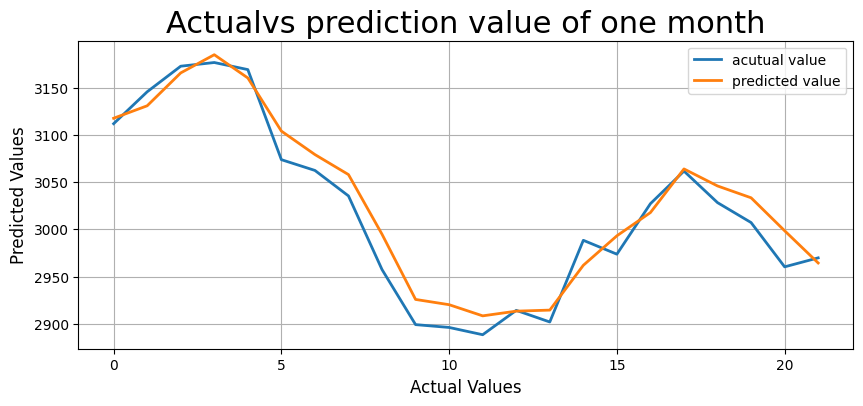

In [168]:
plt.figure(figsize=(10,4))
plt.plot(y2,label="acutual value",linewidth=2)
plt.plot(y1,label="predicted value",linewidth=2)
plt.title("Actualvs prediction value of one month",fontsize=22)
plt.xlabel('Actual Values', fontsize=12)
plt.ylabel('Predicted Values', fontsize=12)
plt.legend()
plt.grid(True)
plt.show()